# Lecture 5: Neural Networks — Companion Notebook

This notebook accompanies the slides. We'll alternate between slides and hands-on coding.

| Section | Topic | After Slide Part |
|---------|-------|------------------|
| 1 | Perceptrons, Logic Gates & XOR Failure | Part 3 |
| 2 | Forward Propagation & XOR Solved | Part 5 |
| 3 | PyTorch Autograd | Part 7 |
| 4 | Training on MNIST | Part 8 |
| 5 | Visualizing What Networks Learn | Part 10 |

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13

---
## Section 1: Perceptrons, Logic Gates & XOR Failure

**Goal:** Build perceptrons from scratch, see what they can and can't do.

### 1.1 The Perceptron

A perceptron computes: $\hat{y} = \text{step}(w_1 x_1 + w_2 x_2 + b)$

where step$(z) = 1$ if $z > 0$, else $0$.

In [9]:
def step(z):
    """Step activation: 1 if z > 0, else 0"""
    return 1 if z > 0 else 0

def perceptron(x1, x2, w1, w2, b):
    """A single perceptron"""
    z = w1 * x1 + w2 * x2 + b
    return step(z)

# AND gate: w1=1, w2=1, b=-1.5
print("AND Gate (w1=1, w2=1, b=-1.5)")
print("-" * 30)
for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    y = perceptron(x1, x2, w1=1, w2=1, b=-1.5)
    print(f"  {x1} AND {x2} = {y}")

AND Gate (w1=1, w2=1, b=-1.5)
------------------------------
  0 AND 0 = 0
  0 AND 1 = 0
  1 AND 0 = 0
  1 AND 1 = 1


In [10]:
# OR gate: w1=1, w2=1, b=-0.5
print("OR Gate (w1=1, w2=1, b=-0.5)")
print("-" * 30)
for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    y = perceptron(x1, x2, w1=1, w2=1, b=-0.5)
    print(f"  {x1} OR {x2} = {y}")

OR Gate (w1=1, w2=1, b=-0.5)
------------------------------
  0 OR 0 = 0
  0 OR 1 = 1
  1 OR 0 = 1
  1 OR 1 = 1


In [11]:
# NOT gate: w1=-1, b=0.5 (single input)
print("NOT Gate (w1=-1, b=0.5)")
print("-" * 30)
for x1 in [0, 1]:
    z = -1 * x1 + 0.5
    y = step(z)
    print(f"  NOT {x1} = {y}")

NOT Gate (w1=-1, b=0.5)
------------------------------
  NOT 0 = 1
  NOT 1 = 0


### 1.2 Visualizing Decision Boundaries

Each perceptron draws a **straight line** that divides the input space.

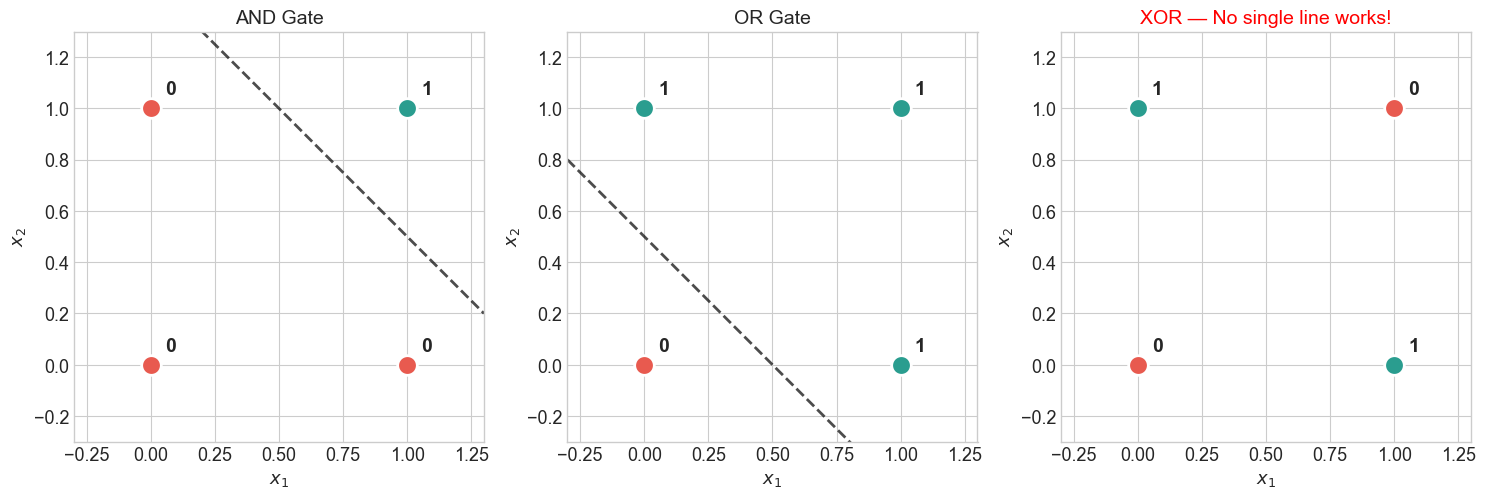

In [37]:
def plot_gate(ax, w1, w2, b, title, truth_table):
    """Plot a perceptron's decision boundary and data points."""
    # Decision boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
    x1_line = np.linspace(-0.3, 1.3, 100)
    if w2 != 0:
        x2_line = -(w1 * x1_line + b) / w2
        ax.plot(x1_line, x2_line, 'k--', linewidth=2, alpha=0.7)
    
    # Plot points
    for (x1, x2), y in truth_table:
        color = '#2a9d8f' if y == 1 else '#e85a4f'
        marker = 'o'
        ax.scatter(x1, x2, c=color, s=200, edgecolors='white', 
                   linewidth=2, zorder=5, marker=marker)
        ax.annotate(str(y), (x1, x2), textcoords="offset points",
                    xytext=(10, 10), fontsize=14, fontweight='bold')
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

and_data = [((0,0),0), ((0,1),0), ((1,0),0), ((1,1),1)]
or_data  = [((0,0),0), ((0,1),1), ((1,0),1), ((1,1),1)]
xor_data = [((0,0),0), ((0,1),1), ((1,0),1), ((1,1),0)]

plot_gate(axes[0], w1=1, w2=1, b=-1.5, title='AND Gate', truth_table=and_data)
plot_gate(axes[1], w1=1, w2=1, b=-0.5, title='OR Gate', truth_table=or_data)

# XOR — no single line works!
for (x1, x2), y in xor_data:
    color = '#2a9d8f' if y == 1 else '#e85a4f'
    axes[2].scatter(x1, x2, c=color, s=200, edgecolors='white', linewidth=2, zorder=5)
    axes[2].annotate(str(y), (x1, x2), textcoords="offset points",
                     xytext=(10, 10), fontsize=14, fontweight='bold')
axes[2].set_xlim(-0.3, 1.3)
axes[2].set_ylim(-0.3, 1.3)
axes[2].set_xlabel('$x_1$')
axes[2].set_ylabel('$x_2$')
axes[2].set_title('XOR — No single line works!', fontsize=14, color='red')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

### 1.3 XOR Fails with Logistic Regression Too

In [38]:
from sklearn.linear_model import LogisticRegression

X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

model_lr = LogisticRegression()
model_lr.fit(X_xor, y_xor)
preds = model_lr.predict(X_xor)

print("Logistic Regression on XOR:")
print(f"  Predictions: {preds}")
print(f"  Actual:      {y_xor}")
print(f"  Accuracy:    {(preds == y_xor).mean():.0%}")
print("\nLogistic regression = 1 neuron with sigmoid. It can't solve XOR either!")

Logistic Regression on XOR:
  Predictions: [0 0 0 0]
  Actual:      [0 1 1 0]
  Accuracy:    50%

Logistic regression = 1 neuron with sigmoid. It can't solve XOR either!


### 1.4 Exercise: Try NAND Yourself

NAND truth table: (0,0)→1, (0,1)→1, (1,0)→1, (1,1)→0

Find `w1`, `w2`, `b` and verify!

In [39]:
# NAND gate: output 1 unless BOTH inputs are 1
# Hint: NAND = NOT(AND), so flip the signs of AND!
w1 = -1
w2 = -1
b  = 1.5

print("NAND Gate (w1=-1, w2=-1, b=1.5)")
print("-" * 35)
nand_expected = [1, 1, 1, 0]
for (x1, x2), expected in zip([(0,0),(0,1),(1,0),(1,1)], nand_expected):
    y = perceptron(x1, x2, w1, w2, b)
    status = "correct" if y == expected else "WRONG"
    print(f"  {x1} NAND {x2} = {y}  (expected {expected}) {status}")

NAND Gate (w1=-1, w2=-1, b=1.5)
-----------------------------------
  0 NAND 0 = 1  (expected 1) correct
  0 NAND 1 = 1  (expected 1) correct
  1 NAND 0 = 1  (expected 1) correct
  1 NAND 1 = 0  (expected 0) correct


---
## Section 2: Forward Propagation & XOR Solved

**Goal:** Build an MLP from scratch and solve XOR with a hidden layer.

### 2.1 Activation Functions

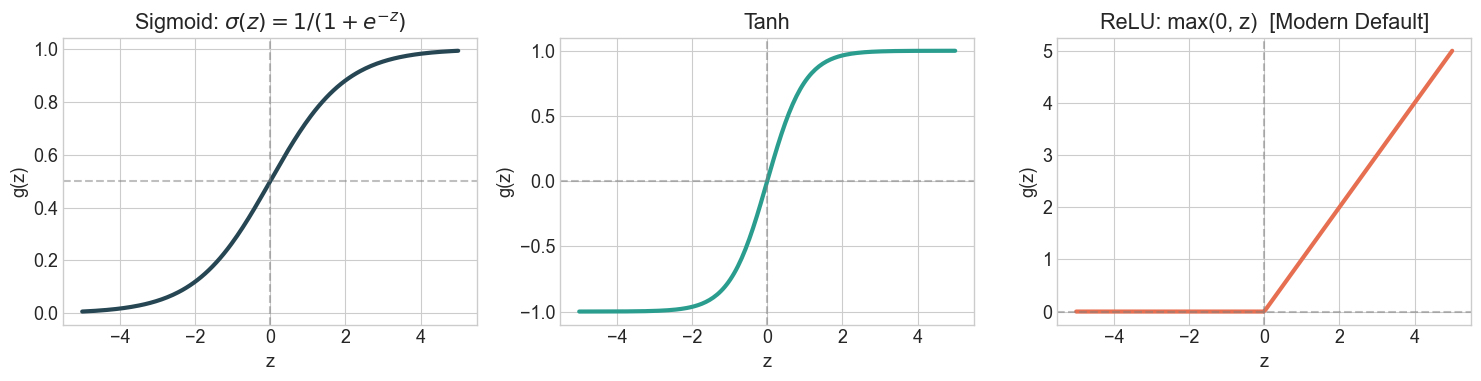

In [40]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, sigmoid(z), linewidth=3, color='#264653')
axes[0].set_title('Sigmoid: $\\sigma(z) = 1/(1+e^{-z})$')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)

axes[1].plot(z, np.tanh(z), linewidth=3, color='#2a9d8f')
axes[1].set_title('Tanh')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)

axes[2].plot(z, relu(z), linewidth=3, color='#e76f51')
axes[2].set_title('ReLU: max(0, z)  [Modern Default]')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('z')
    ax.set_ylabel('g(z)')

plt.tight_layout()
plt.show()

### 2.2 Solving XOR with a 2-Layer Network

**Architecture:** 2 inputs → 2 hidden (step) → 1 output (step)

- $h_1 = \text{step}(x_1 + x_2 - 0.5)$ — acts like OR  
- $h_2 = \text{step}(x_1 + x_2 - 1.5)$ — acts like AND  
- $\hat{y} = \text{step}(h_1 - 2h_2 - 0.5)$ — OR AND NOT AND = XOR!

In [41]:
def xor_network(x1, x2):
    """Hand-built MLP that solves XOR."""
    # Hidden layer
    h1 = step(1*x1 + 1*x2 - 0.5)   # OR
    h2 = step(1*x1 + 1*x2 - 1.5)   # AND
    
    # Output layer
    y_hat = step(1*h1 - 2*h2 - 0.5)  # OR AND NOT AND
    
    return h1, h2, y_hat

print("XOR solved with a 2-layer network!")
print(f"{'x1':>3} {'x2':>3} | {'h1(OR)':>7} {'h2(AND)':>8} | {'y_hat':>5} {'expected':>9}")
print("-" * 50)
for x1, x2, expected in [(0,0,0), (0,1,1), (1,0,1), (1,1,0)]:
    h1, h2, y_hat = xor_network(x1, x2)
    status = "correct" if y_hat == expected else "WRONG"
    print(f"{x1:>3} {x2:>3} | {h1:>7} {h2:>8} | {y_hat:>5} {expected:>9}  {status}")

XOR solved with a 2-layer network!
 x1  x2 |  h1(OR)  h2(AND) | y_hat  expected
--------------------------------------------------
  0   0 |       0        0 |     0         0  correct
  0   1 |       1        0 |     1         1  correct
  1   0 |       1        0 |     1         1  correct
  1   1 |       1        1 |     0         0  correct


### 2.3 The Hidden Layer Transforms the Space!

Let's visualize how the hidden layer maps the XOR points into a new space where they become **linearly separable**.

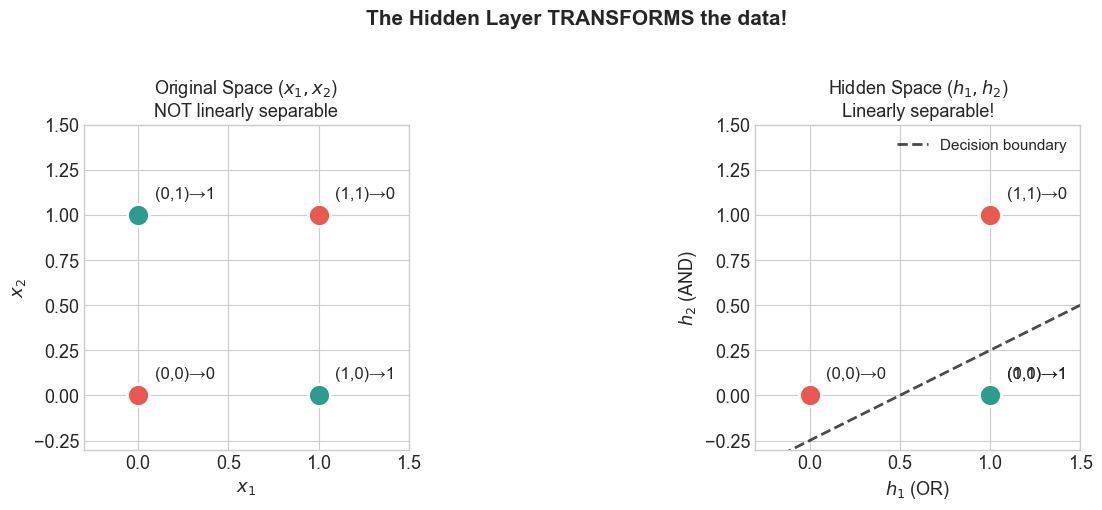

Key insight: (0,1) and (1,0) both map to (1,0) in hidden space — they collapse!
Now a single line can separate class 0 from class 1.


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original space
for (x1, x2), y in zip(X_xor, y_xor):
    color = '#2a9d8f' if y == 1 else '#e85a4f'
    axes[0].scatter(x1, x2, c=color, s=250, edgecolors='white', linewidth=2, zorder=5)
    axes[0].annotate(f'({x1},{x2})→{y}', (x1, x2), textcoords="offset points",
                     xytext=(12, 12), fontsize=12)
axes[0].set_title('Original Space ($x_1, x_2$)\nNOT linearly separable', fontsize=13)
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_xlim(-0.3, 1.5)
axes[0].set_ylim(-0.3, 1.5)
axes[0].set_aspect('equal')

# Hidden space
hidden_points = []
for (x1, x2), y in zip(X_xor, y_xor):
    h1, h2, _ = xor_network(x1, x2)
    hidden_points.append((h1, h2, y))
    color = '#2a9d8f' if y == 1 else '#e85a4f'
    axes[1].scatter(h1, h2, c=color, s=250, edgecolors='white', linewidth=2, zorder=5)
    axes[1].annotate(f'({x1},{x2})→{y}', (h1, h2), textcoords="offset points",
                     xytext=(12, 12), fontsize=12)

# Draw separating line in hidden space
h1_line = np.linspace(-0.3, 1.5, 100)
# h1 - 2*h2 - 0.5 = 0  =>  h2 = (h1 - 0.5) / 2
h2_line = (h1_line - 0.5) / 2
axes[1].plot(h1_line, h2_line, 'k--', linewidth=2, alpha=0.7, label='Decision boundary')

axes[1].set_title('Hidden Space ($h_1, h_2$)\nLinearly separable!', fontsize=13)
axes[1].set_xlabel('$h_1$ (OR)')
axes[1].set_ylabel('$h_2$ (AND)')
axes[1].set_xlim(-0.3, 1.5)
axes[1].set_ylim(-0.3, 1.5)
axes[1].set_aspect('equal')
axes[1].legend(fontsize=11)

plt.suptitle('The Hidden Layer TRANSFORMS the data!', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: (0,1) and (1,0) both map to (1,0) in hidden space — they collapse!")
print("Now a single line can separate class 0 from class 1.")

### 2.4 Forward Pass with Numpy — Same Example from Slides

**Network:** 2 inputs → 2 hidden (ReLU) → 1 output (sigmoid)

Follow along with the slides!

In [43]:
# Same weights as in the slides!
# Hidden layer: 2 neurons, each with 2 input weights + 1 bias
W1 = np.array([[0.5, 0.8],    # neuron h1: weights for x1, x2
               [-0.3, 0.6]])   # neuron h2: weights for x1, x2
b1 = np.array([-0.1, 0.2])     # biases for h1, h2

# Output layer: 1 neuron with 2 input weights + 1 bias
w2 = np.array([0.7, -0.5])     # weights from h1, h2
b2 = -0.1                       # bias

# Input
x = np.array([1.0, 0.5])

# Forward pass — step by step
print("=== Forward Pass ===\n")

print("Step 1: Hidden layer — weighted sums")
z1 = W1 @ x + b1
print(f"  z1 = {W1[0,0]}*{x[0]} + {W1[0,1]}*{x[1]} + ({b1[0]}) = {z1[0]:.1f}")
print(f"  z2 = {W1[1,0]}*{x[0]} + {W1[1,1]}*{x[1]} + {b1[1]} = {z1[1]:.1f}")

print(f"\nStep 2: ReLU activation")
h = relu(z1)
print(f"  h1 = max(0, {z1[0]:.1f}) = {h[0]:.1f}")
print(f"  h2 = max(0, {z1[1]:.1f}) = {h[1]:.1f}")

print(f"\nStep 3: Output — weighted sum")
z_out = w2 @ h + b2
print(f"  z_out = {w2[0]}*{h[0]:.1f} + ({w2[1]})*{h[1]:.1f} + ({b2}) = {z_out:.2f}")

print(f"\nStep 4: Sigmoid activation")
y_hat = sigmoid(z_out)
print(f"  y_hat = sigmoid({z_out:.2f}) = {y_hat:.3f}")
print(f"\nPrediction: {y_hat:.0%} probability of class 1")

=== Forward Pass ===

Step 1: Hidden layer — weighted sums
  z1 = 0.5*1.0 + 0.8*0.5 + (-0.1) = 0.8
  z2 = -0.3*1.0 + 0.6*0.5 + 0.2 = 0.2

Step 2: ReLU activation
  h1 = max(0, 0.8) = 0.8
  h2 = max(0, 0.2) = 0.2

Step 3: Output — weighted sum
  z_out = 0.7*0.8 + (-0.5)*0.2 + (-0.1) = 0.36

Step 4: Sigmoid activation
  y_hat = sigmoid(0.36) = 0.589

Prediction: 59% probability of class 1


### 2.5 Counting Parameters

In [19]:
def count_params(layers):
    """Count parameters for a fully-connected network.
    layers: list of layer sizes, e.g. [784, 128, 10]
    """
    total = 0
    print(f"Network: {' -> '.join(map(str, layers))}")
    print("-" * 50)
    for i in range(len(layers) - 1):
        weights = layers[i] * layers[i+1]
        biases = layers[i+1]
        layer_total = weights + biases
        total += layer_total
        print(f"  Layer {i+1}: {layers[i]}x{layers[i+1]} weights + {layers[i+1]} biases = {layer_total:,}")
    print(f"  Total: {total:,} parameters")
    return total

# MNIST classifier
count_params([784, 128, 10])
print()

# Deeper network
count_params([784, 256, 128, 64, 10])

Network: 784 -> 128 -> 10
--------------------------------------------------
  Layer 1: 784x128 weights + 128 biases = 100,480
  Layer 2: 128x10 weights + 10 biases = 1,290
  Total: 101,770 parameters

Network: 784 -> 256 -> 128 -> 64 -> 10
--------------------------------------------------
  Layer 1: 784x256 weights + 256 biases = 200,960
  Layer 2: 256x128 weights + 128 biases = 32,896
  Layer 3: 128x64 weights + 64 biases = 8,256
  Layer 4: 64x10 weights + 10 biases = 650
  Total: 242,762 parameters


242762

### 2.6 Why Non-Linearity Matters

Without activation functions, stacking layers is pointless!

In [44]:
# Stacking linear layers = still linear
np.random.seed(42)
W_a = np.random.randn(3, 2)
b_a = np.random.randn(3)
W_b = np.random.randn(1, 3)
b_b = np.random.randn(1)

x = np.array([1.0, 2.0])

# Two linear layers
h = W_a @ x + b_a
y_two_layers = W_b @ h + b_b

# Equivalent single layer
W_combined = W_b @ W_a
b_combined = W_b @ b_a + b_b
y_one_layer = W_combined @ x + b_combined

print(f"Two linear layers: {y_two_layers[0]:.6f}")
print(f"One combined layer: {y_one_layer[0]:.6f}")
print(f"Same? {np.allclose(y_two_layers, y_one_layer)}")
print("\n100 linear layers = 1 linear layer. Depth without non-linearity is useless!")

Two linear layers: -0.303358
One combined layer: -0.303358
Same? True

100 linear layers = 1 linear layer. Depth without non-linearity is useless!


---
## Section 3: PyTorch Autograd

**Goal:** See how PyTorch computes gradients automatically — no manual backprop needed!

In [45]:
import torch
import torch.nn as nn

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1


### 3.1 Simple Gradient: $y = x^2 + 3x$

In [46]:
# Create a tensor that tracks gradients
x = torch.tensor([2.0], requires_grad=True)

# Forward: compute y = x^2 + 3x
y = x**2 + 3*x  # y = 4 + 6 = 10
print(f"x = {x.item()},  y = x^2 + 3x = {y.item()}")

# Backward: compute dy/dx
y.backward()

print(f"dy/dx = 2x + 3 = 2({x.item()}) + 3 = {x.grad.item()}")
print(f"PyTorch computed: {x.grad.item()}")

x = 2.0,  y = x^2 + 3x = 10.0
dy/dx = 2x + 3 = 2(2.0) + 3 = 7.0
PyTorch computed: 7.0


### 3.2 Chain Rule: $y = \sigma(w \cdot x + b)$

This is exactly what happens inside a single neuron!

In [47]:
# A single neuron
w = torch.tensor([0.5], requires_grad=True)
b = torch.tensor([0.1], requires_grad=True)
x = torch.tensor([2.0])  # input (no grad needed — we don't update inputs)

# Forward pass
z = w * x + b          # weighted sum
y_hat = torch.sigmoid(z)  # activation

# True label
y_true = torch.tensor([1.0])

# Loss (binary cross-entropy by hand)
loss = -(y_true * torch.log(y_hat) + (1 - y_true) * torch.log(1 - y_hat))

print(f"z = w*x + b = {z.item():.3f}")
print(f"y_hat = sigmoid(z) = {y_hat.item():.3f}")
print(f"loss = {loss.item():.3f}")

# Backward — compute ALL gradients in one call!
loss.backward()

print(f"\ndloss/dw = {w.grad.item():.4f}")
print(f"dloss/db = {b.grad.item():.4f}")
print("\nPyTorch applied the chain rule through sigmoid, multiplication, and log — automatically!")

z = w*x + b = 1.100
y_hat = sigmoid(z) = 0.750
loss = 0.287

dloss/dw = -0.4995
dloss/db = -0.2497

PyTorch applied the chain rule through sigmoid, multiplication, and log — automatically!


### 3.3 Gradient Descent in Action

Let's watch a neuron learn to output 1 for input x=2.

Step  0: w=0.500, b=0.250, pred=0.500, loss=0.6931
Step  5: w=1.117, b=0.558, pred=0.932, loss=0.0701
Step 10: w=1.346, b=0.673, pred=0.964, loss=0.0371
Step 15: w=1.491, b=0.745, pred=0.975, loss=0.0253
Step 20: w=1.596, b=0.798, pred=0.981, loss=0.0192
Step 25: w=1.680, b=0.840, pred=0.985, loss=0.0155


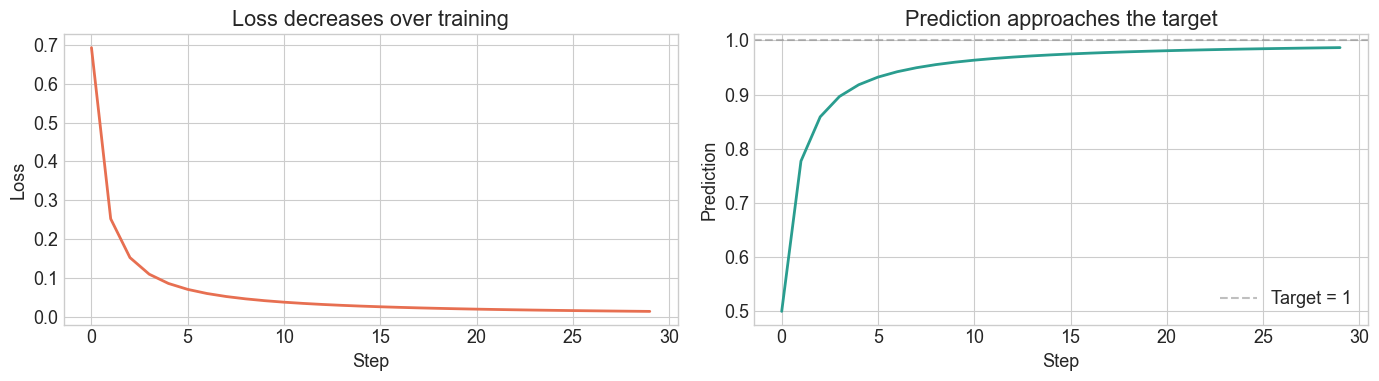

In [48]:
# A single neuron learning
w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)
x = torch.tensor([2.0])
y_true = torch.tensor([1.0])
lr = 0.5

losses = []
predictions = []

for step_num in range(30):
    # Forward
    y_hat = torch.sigmoid(w * x + b)
    loss = -(y_true * torch.log(y_hat) + (1 - y_true) * torch.log(1 - y_hat))
    
    losses.append(loss.item())
    predictions.append(y_hat.item())
    
    # Backward
    loss.backward()
    
    # Update weights (gradient descent)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    
    # Clear gradients for next step
    w.grad.zero_()
    b.grad.zero_()
    
    if step_num % 5 == 0:
        print(f"Step {step_num:2d}: w={w.item():.3f}, b={b.item():.3f}, "
              f"pred={y_hat.item():.3f}, loss={loss.item():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses, linewidth=2, color='#e76f51')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss decreases over training')

axes[1].plot(predictions, linewidth=2, color='#2a9d8f')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Target = 1')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Prediction')
axes[1].set_title('Prediction approaches the target')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Exercise: Try Different Learning Rates

What happens with `lr=0.01` (too small)? `lr=5.0` (too large)?

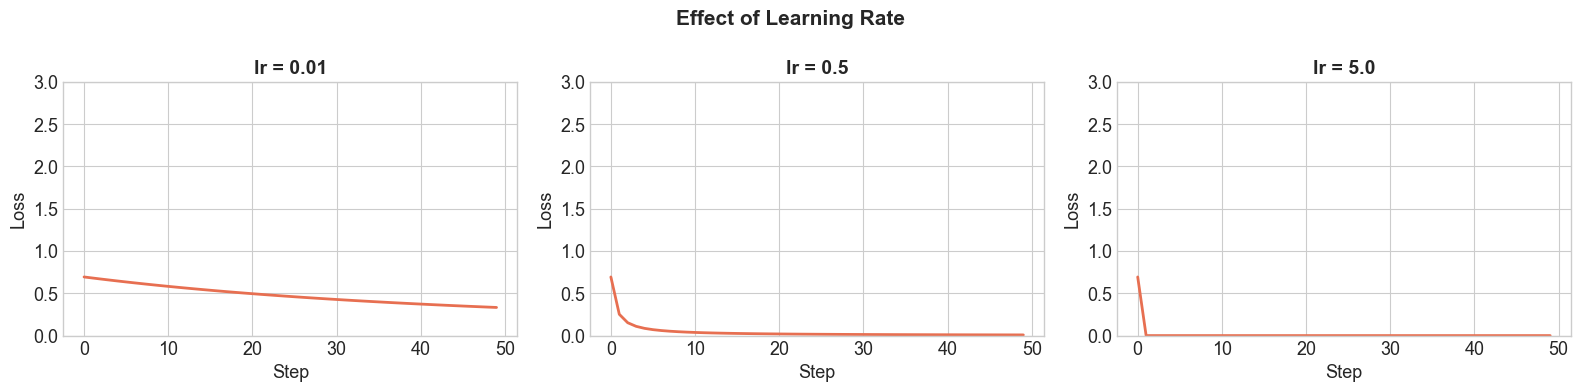

lr=0.01: Too slow — barely learns in 50 steps
lr=0.5:  Just right — smooth convergence
lr=5.0:  Too large — loss may oscillate or explode


In [49]:
# Let's compare learning rates side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, lr in zip(axes, [0.01, 0.5, 5.0]):
    w = torch.tensor([0.0], requires_grad=True)
    b = torch.tensor([0.0], requires_grad=True)
    x = torch.tensor([2.0])
    y_true = torch.tensor([1.0])
    losses = []

    for _ in range(50):
        y_hat = torch.sigmoid(w * x + b)
        loss = -(y_true * torch.log(y_hat + 1e-8) + (1 - y_true) * torch.log(1 - y_hat + 1e-8))
        losses.append(loss.item())
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    ax.plot(losses, linewidth=2, color='#e76f51')
    ax.set_title(f'lr = {lr}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_ylim(0, max(3, max(losses[:10])))

plt.suptitle('Effect of Learning Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("lr=0.01: Too slow — barely learns in 50 steps")
print("lr=0.5:  Just right — smooth convergence")
print("lr=5.0:  Too large — loss may oscillate or explode")

---
## Section 4: Training on MNIST

**Goal:** Train a neural network to classify handwritten digits — the "Hello World" of deep learning!

In [50]:
from torchvision import datasets, transforms

# Load MNIST as tensors (no DataLoader needed for now!)
train_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
test_data  = datasets.MNIST('data', train=False, download=True, transform=transforms.ToTensor())

# Convert entire dataset to tensors — simple and direct
X_train = train_data.data.float() / 255.0   # normalize to [0,1]
y_train = train_data.targets
X_test  = test_data.data.float() / 255.0
y_test  = test_data.targets

print(f"Training: {X_train.shape} images, {y_train.shape} labels")
print(f"Test:     {X_test.shape} images, {y_test.shape} labels")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"Classes: {sorted(y_train.unique().tolist())}")

Training: torch.Size([60000, 28, 28]) images, torch.Size([60000]) labels
Test:     torch.Size([10000, 28, 28]) images, torch.Size([10000]) labels
Pixel range: [0.0, 1.0]
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


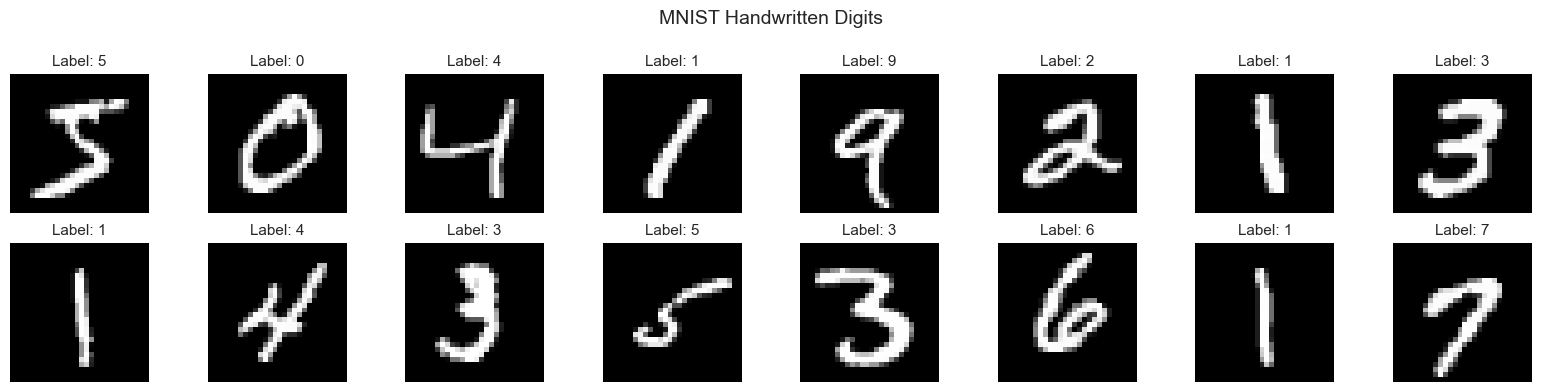

In [51]:
# Let's look at some examples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i].item()}', fontsize=11)
    ax.axis('off')
plt.suptitle('MNIST Handwritten Digits', fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 Define the Network

**Quick way:** `nn.Sequential` (just stack layers)

In [52]:
# Quick way: nn.Sequential (just stack layers in order)
model_sequential = nn.Sequential(
    nn.Flatten(),          # 28x28 image -> 784-dim vector
    nn.Linear(784, 128),   # Input -> Hidden
    nn.ReLU(),             # Non-linearity
    nn.Linear(128, 10)     # Hidden -> Output (10 digits)
)

total = sum(p.numel() for p in model_sequential.parameters())
print(f"Sequential model:\n{model_sequential}")
print(f"\nTotal parameters: {total:,}")

Sequential model:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 101,770


**Better way: Object-Oriented model with `nn.Module`**

This gives us more control. We'll use this style going forward.

In [53]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.flatten(x)    # 28x28 -> 784
        x = self.hidden(x)     # 784 -> 128
        x = self.relu(x)       # non-linearity
        x = self.output(x)     # 128 -> 10
        return x

model = MNISTNet()
total = sum(p.numel() for p in model.parameters())
print(f"OO model:\n{model}")
print(f"\nTotal parameters: {total:,}")
print("\nSame architecture, but now we can add custom logic in forward().")

OO model:
MNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 101,770

Same architecture, but now we can add custom logic in forward().


### 4.3 The Training Loop

The exact same 4 steps, repeated: **forward → loss → backward → update**

In [54]:
# Training with plain tensors — no DataLoader needed!
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
batch_size = 64
n_epochs = 5

# Flatten images for our model
X_train_flat = X_train.view(-1, 1, 28, 28)  # add channel dim
X_test_flat = X_test.view(-1, 1, 28, 28)

train_losses = []
test_accs = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    n_batches = 0
    
    # Shuffle training data each epoch
    perm = torch.randperm(len(X_train))
    X_shuffled = X_train_flat[perm]
    y_shuffled = y_train[perm]
    
    # Mini-batch training
    for i in range(0, len(X_train), batch_size):
        images = X_shuffled[i:i+batch_size]
        labels = y_shuffled[i:i+batch_size]
        
        # The 4 steps:
        output = model(images)                              # 1. Forward
        loss = nn.functional.cross_entropy(output, labels)  # 2. Loss
        optimizer.zero_grad()                               # Clear old gradients
        loss.backward()                                     # 3. Backward
        optimizer.step()                                    # 4. Update
        
        epoch_loss += loss.item()
        n_batches += 1
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_output = model(X_test_flat)
        test_preds = test_output.argmax(1)
        test_acc = (test_preds == y_test).float().mean().item()
    
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{n_epochs}:  Loss = {avg_loss:.4f},  Test Accuracy = {test_acc:.1%}")

print(f"\nFinal test accuracy: {test_accs[-1]:.1%}")

Epoch 1/5:  Loss = 0.3449,  Test Accuracy = 94.7%
Epoch 2/5:  Loss = 0.1539,  Test Accuracy = 96.0%
Epoch 3/5:  Loss = 0.1102,  Test Accuracy = 97.0%
Epoch 4/5:  Loss = 0.0823,  Test Accuracy = 97.4%
Epoch 5/5:  Loss = 0.0654,  Test Accuracy = 97.4%

Final test accuracy: 97.4%


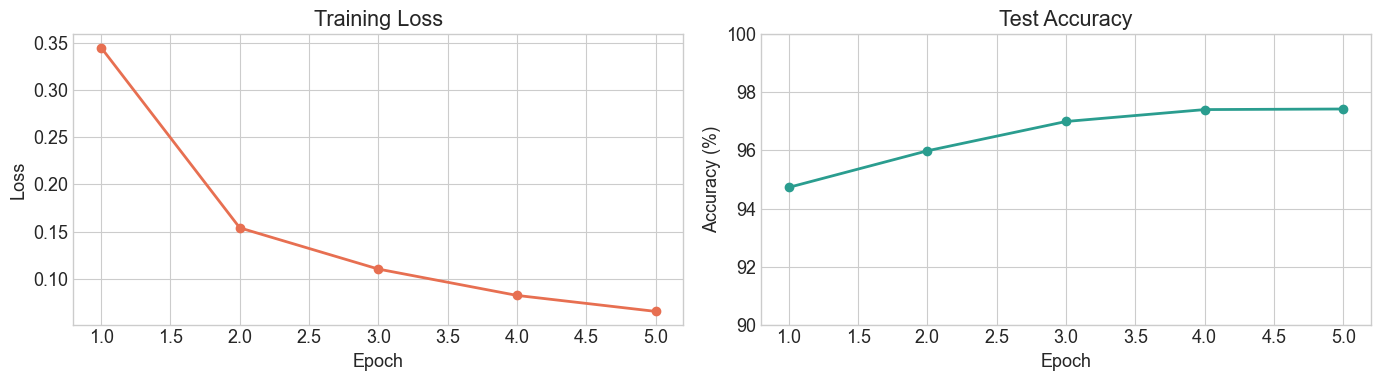

In [55]:
# Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, n_epochs+1), train_losses, 'o-', linewidth=2, color='#e76f51')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')

axes[1].plot(range(1, n_epochs+1), [a*100 for a in test_accs], 'o-', linewidth=2, color='#2a9d8f')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy')
axes[1].set_ylim(90, 100)

plt.tight_layout()
plt.show()

### 4.4 Let's See Some Predictions

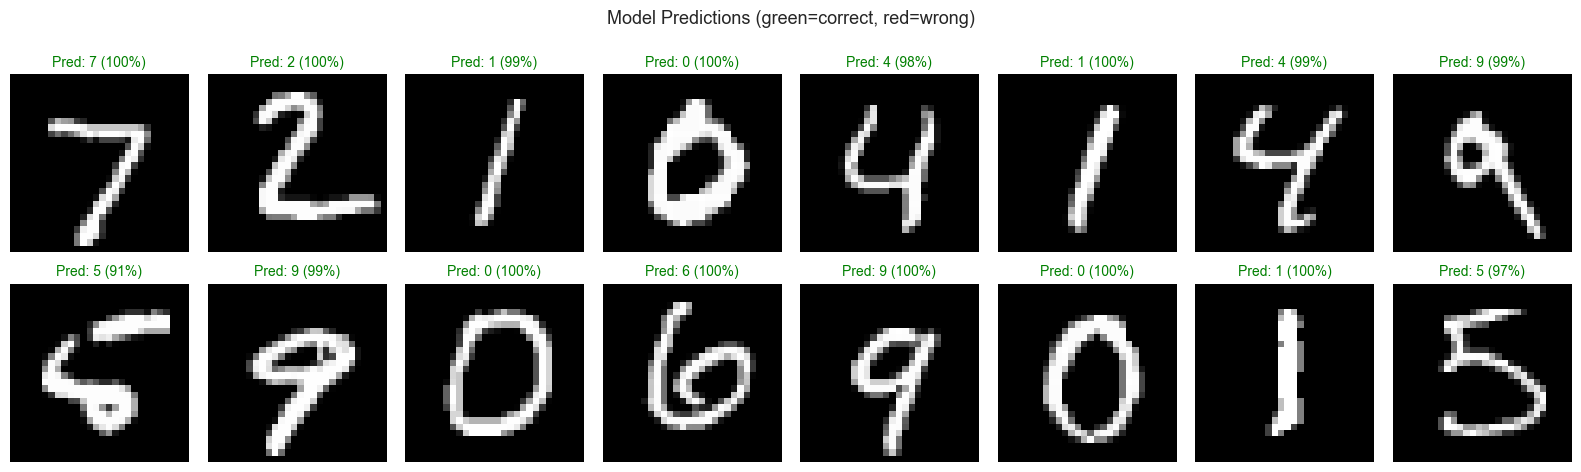

In [56]:
# Show predictions on test images
model.eval()
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for i, ax in enumerate(axes.flat):
    img = X_test[i]
    true_label = y_test[i].item()
    with torch.no_grad():
        logits = model(img.view(1, 1, 28, 28))
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(1).item()
        conf = probs[0, pred].item()
    
    ax.imshow(img, cmap='gray')
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f'Pred: {pred} ({conf:.0%})', fontsize=10, color=color)
    ax.axis('off')

plt.suptitle('Model Predictions (green=correct, red=wrong)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5: Visualizing What the Network Learns

**Goal:** Look inside the "black box" — what do the hidden layer weights look like?

### 5.1 Visualizing First Layer Weights

Each hidden neuron has 784 weights — one per pixel. We can reshape them back to 28x28 to see what pattern each neuron looks for.

First layer weight shape: (128, 784)
Each of the 128 neurons has 784 weights (one per pixel)


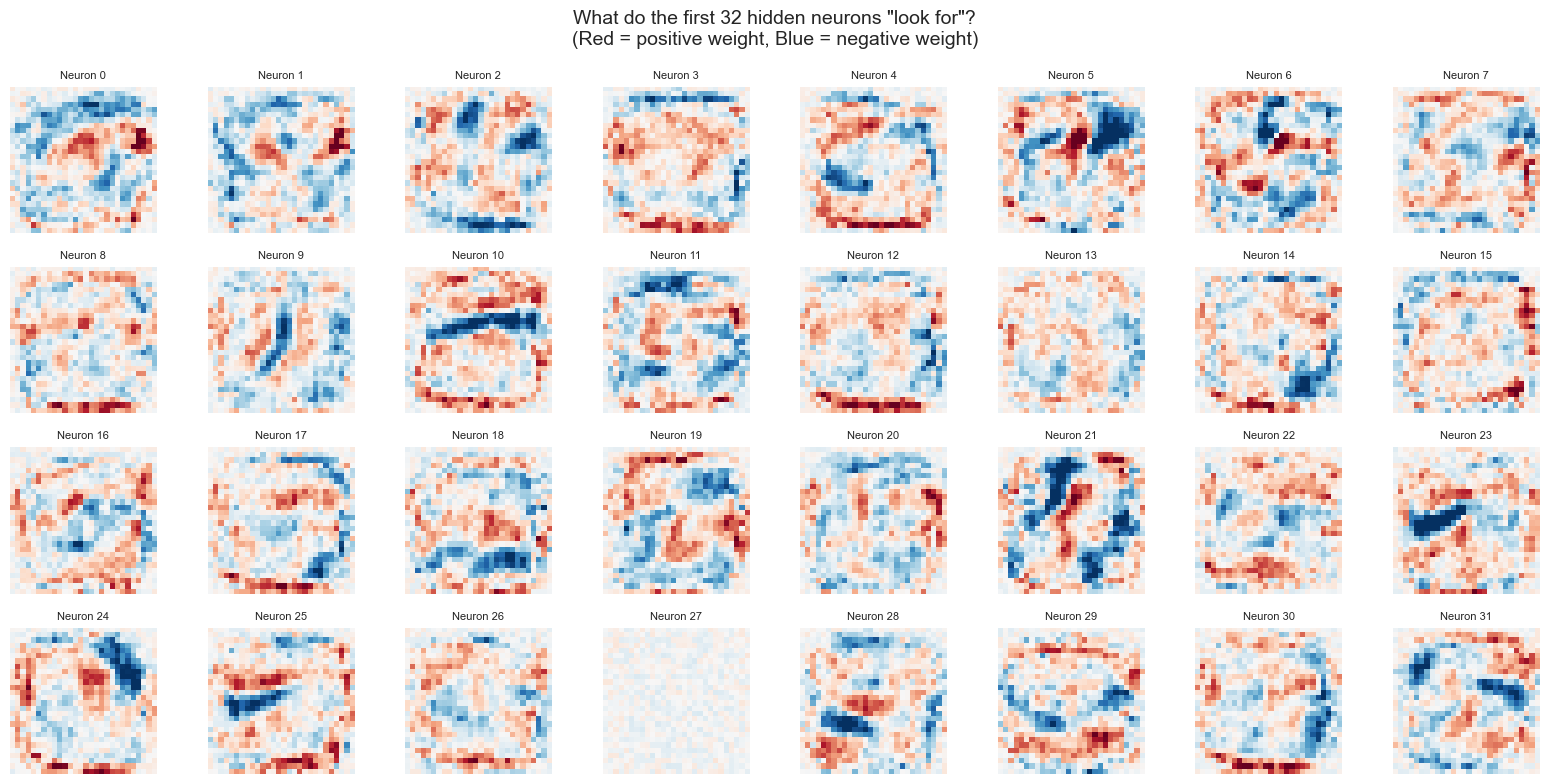

Each neuron learns to detect a different pattern in the image!
Some look like edge detectors, some like digit templates.


In [57]:
# Extract first layer weights from our OO model
weights = model.hidden.weight.data.numpy()  # shape: (128, 784)

print(f"First layer weight shape: {weights.shape}")
print(f"Each of the 128 neurons has 784 weights (one per pixel)")

# Visualize 32 neurons' weight patterns
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    w = weights[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    ax.set_title(f'Neuron {i}', fontsize=8)
    ax.axis('off')

plt.suptitle('What do the first 32 hidden neurons "look for"?\n'
             '(Red = positive weight, Blue = negative weight)', fontsize=14)
plt.tight_layout()
plt.show()

print("Each neuron learns to detect a different pattern in the image!")
print("Some look like edge detectors, some like digit templates.")

### 5.2 What Activates Each Neuron?

Activations shape: torch.Size([10000, 128])  (examples x neurons)


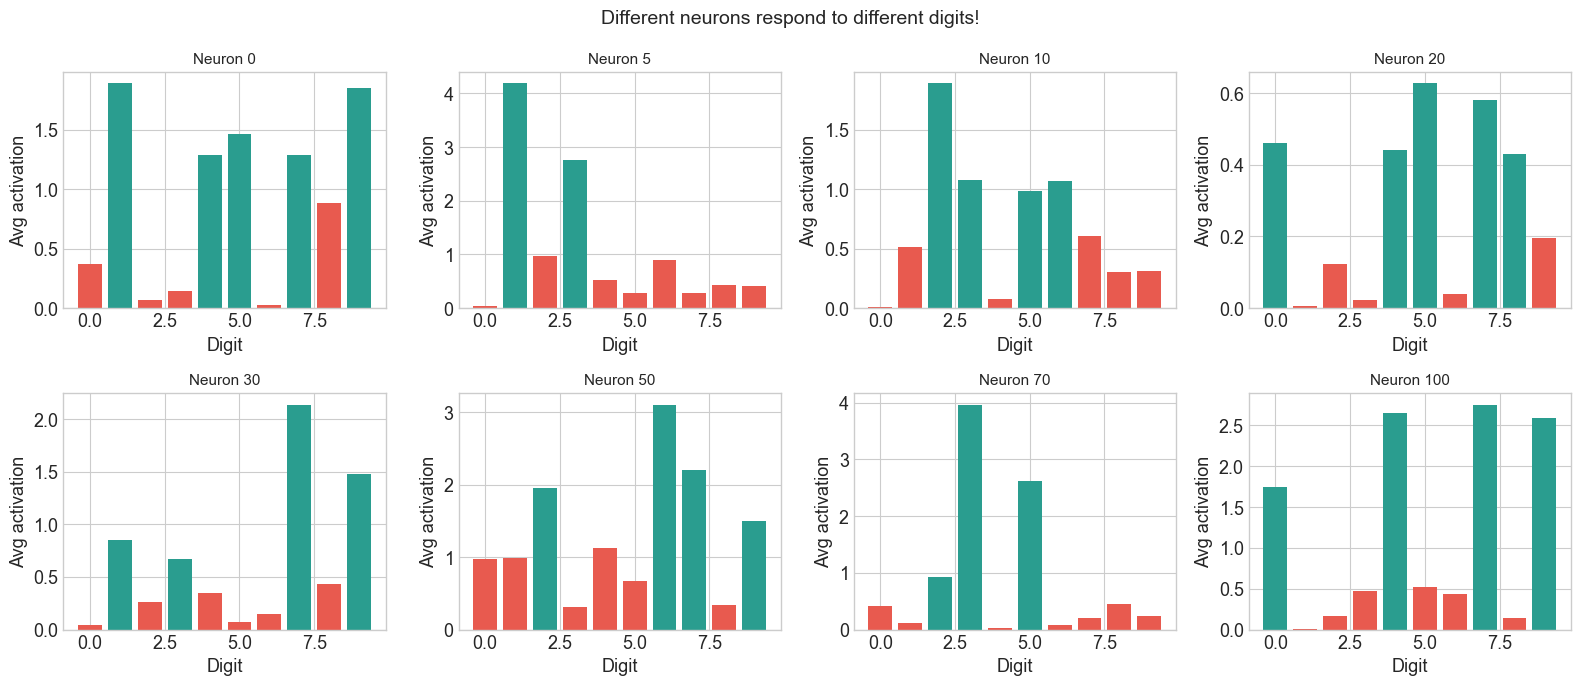

In [58]:
# What activates each neuron? Average activation per digit class.
model.eval()
with torch.no_grad():
    flat = X_test.view(-1, 784)
    acts = torch.relu(model.hidden(flat))  # hidden layer activations

print(f"Activations shape: {acts.shape}  (examples x neurons)")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
neurons_to_show = [0, 5, 10, 20, 30, 50, 70, 100]

for ax, neuron_idx in zip(axes.flat, neurons_to_show):
    avg_act = [acts[y_test == d, neuron_idx].mean().item() for d in range(10)]
    colors = ['#2a9d8f' if a > np.mean(avg_act) else '#e85a4f' for a in avg_act]
    ax.bar(range(10), avg_act, color=colors)
    ax.set_title(f'Neuron {neuron_idx}', fontsize=11)
    ax.set_xlabel('Digit')
    ax.set_ylabel('Avg activation')

plt.suptitle('Different neurons respond to different digits!', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix — Where Does It Go Wrong?

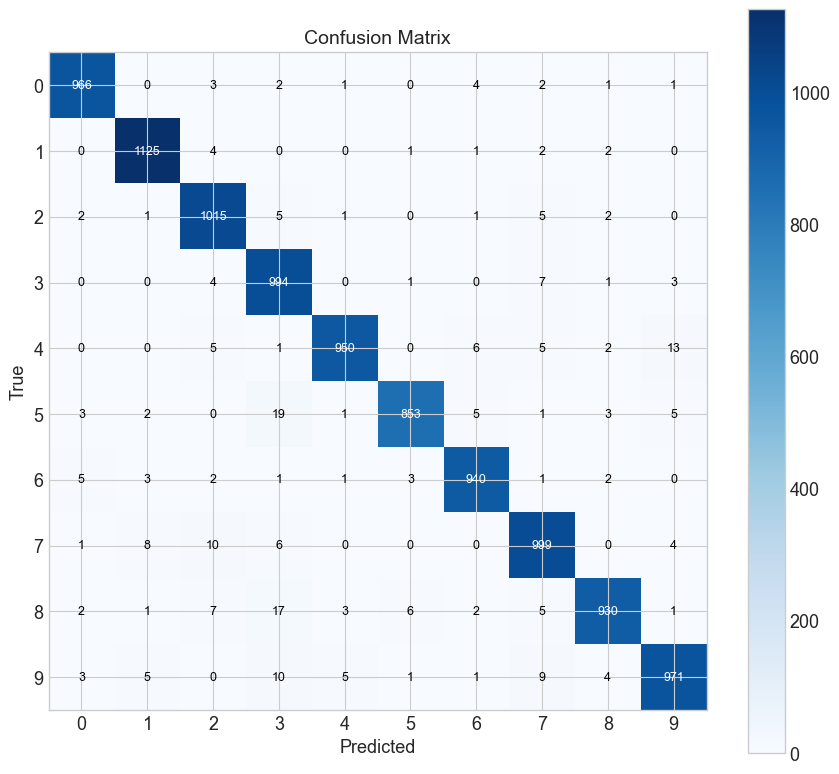

Most confused pair: 5 mistaken for 3 (19 times)


In [59]:
# Confusion matrix — no DataLoader needed
model.eval()
with torch.no_grad():
    all_preds = model(X_test_flat).argmax(1).numpy()
    all_labels = y_test.numpy()

conf_matrix = np.zeros((10, 10), dtype=int)
for true, pred in zip(all_labels, all_preds):
    conf_matrix[true, pred] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf_matrix, cmap='Blues')

for i in range(10):
    for j in range(10):
        color = 'white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black'
        ax.text(j, i, str(conf_matrix[i, j]), ha='center', va='center',
                fontsize=9, color=color)

ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('Confusion Matrix', fontsize=14)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Most confused pairs
cm = conf_matrix.copy()
np.fill_diagonal(cm, 0)
worst = np.unravel_index(cm.argmax(), cm.shape)
print(f"Most confused pair: {worst[0]} mistaken for {worst[1]} ({cm[worst]} times)")

### 5.4 From Classification to Generation (Bridge to Lecture 7)

What if instead of classifying images, we predict the **next character** in text?

Same architecture. Same training loop. Different data.

In [60]:
# Quick demo: character-level prediction
text = "the cat sat on the mat the cat sat on the hat"
chars = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

print(f"Text: '{text}'")
print(f"Vocabulary: {chars}")
print(f"Vocab size: {len(chars)}")
print(f"\nCharacter encoding:")
for c, i in sorted(char_to_idx.items()):
    print(f"  '{c}' → {i}")

print("\nTask: Given 3 characters, predict the 4th.")
print("  'the' → ' '")
print("  'e c' → 'a'")
print("  'cat' → ' '")
print("\nThis is the SAME as MNIST: input → neural network → softmax → class.")
print("Just classes are characters instead of digits!")
print("\nMore on this in Lecture 7...")

Text: 'the cat sat on the mat the cat sat on the hat'
Vocabulary: [' ', 'a', 'c', 'e', 'h', 'm', 'n', 'o', 's', 't']
Vocab size: 10

Character encoding:
  ' ' → 0
  'a' → 1
  'c' → 2
  'e' → 3
  'h' → 4
  'm' → 5
  'n' → 6
  'o' → 7
  's' → 8
  't' → 9

Task: Given 3 characters, predict the 4th.
  'the' → ' '
  'e c' → 'a'
  'cat' → ' '

This is the SAME as MNIST: input → neural network → softmax → class.
Just classes are characters instead of digits!

More on this in Lecture 7...


---
## Summary

| Section | What We Did |
|---------|-------------|
| 1 | Built perceptrons for AND, OR, NOT — saw XOR fail |
| 2 | Built a 2-layer MLP that solves XOR; traced forward pass |
| 3 | Used PyTorch autograd — gradients computed automatically |
| 4 | Trained MNIST classifier to ~97% accuracy in 5 epochs |
| 5 | Visualized weights, activations, and confusion matrix |

**Key takeaway:** The same forward → loss → backward → update loop powers everything from XOR to ChatGPT.